In [1]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from math import gcd, isqrt
from fractions import Fraction
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# CLASSICAL ALGORITHMS

In [2]:
# Trial division: tests every odd divisor up to √N. O(√N) queries. Returns (p, q, queries).
def classical_trial_division(N):
    if N < 2:
        return None, None, 0
    if N % 2 == 0:
        return 2, N // 2, 1

    queries = 1
    for i in range(3, isqrt(N) + 1, 2):
        queries += 1
        if N % i == 0:
            return i, N // i, queries

    return None, None, queries

In [3]:
# Pollard's rho: probabilistic sub-exponential factoring. O(N^(1/4)) expected. Returns (p, q, queries).
def classical_pollard_rho(N, x0=2, max_iter=10_000_000):
    if N < 2:
        return None, None, 0
    if N % 2 == 0:
        return 2, N // 2, 1

    x, y, d, queries = x0, x0, 1, 0
    f = lambda x: (x * x + 1) % N
    while d == 1:
        x = f(x)
        y = f(f(y))
        d = gcd(abs(x - y), N)
        queries += 1
        if queries >= max_iter:
            return None, None, queries      # give up

    if d == N:
        return None, None, queries          # cycle detected, no factor found

    return d, N // d, queries

# QUANTUM ALGORITHM (Shor)

In [4]:
# Inverse Quantum Fourier Transform on n_count qubits.
def inverse_qft(n_count):
    qc = QuantumCircuit(n_count, name='inv_QFT')

    # Bit-reversal permutation
    for j in range(n_count // 2):
        qc.swap(j, n_count - 1 - j)

    # Inverse controlled phase rotations then Hadamard, iterated from MSB downto LSB
    for j in range(n_count - 1, -1, -1):
        for k in range(n_count - 1, j, -1):
            qc.cp(-np.pi / 2 ** (k - j), k, j)
        qc.h(j)

    return qc

In [5]:
# Permutation unitary for multiplication by a_pow mod N on n_target qubits.
# U|y⟩ = |a_pow · y mod N⟩  for y < N;  U|y⟩ = |y⟩  for y >= N.
# This is a valid unitary because multiplication by a is a bijection on Z_N when gcd(a,N)=1.
def _mod_mult_unitary(a_pow, N, n_target):
    dim = 2 ** n_target
    U = np.zeros((dim, dim), dtype=complex)
    for y in range(dim):
        dest = (a_pow * y) % N if y < N else y
        U[dest, y] = 1.0
    return U


# Correct QPE circuit for Shor's algorithm.
#
# For each counting qubit j, applies controlled-U^(2^j) where U|y⟩ = |a·y mod N⟩.
# The unitary is the exact permutation matrix for multiplication by a^(2^j) mod N,
# so genuine phase kickback occurs: the eigenvalues of U are e^(2πi·k/r) (k=0..r-1),
# and QPE peaks the counting register at multiples of 2^n_count / r after IQFT.
#
# Trade-off: building the full 2^n_target × 2^n_target unitary is exponential in n_target,
# but for small N (as benchmarked here) this is tractable and produces correct results.
def shor_qpe_circuit(N, a, n_count):
    n_target = N.bit_length()
    total    = n_count + n_target
    qc       = QuantumCircuit(total, n_count, name='Shor_QPE')

    qc.x(n_count)            # |1⟩ in target register
    qc.h(range(n_count))     # uniform superposition in counting register

    for j in range(n_count):
        a_pow_j = pow(a, 2 ** j, N)          # classical pre-computation
        c_u = UnitaryGate(_mod_mult_unitary(a_pow_j, N, n_target),
                          label=f'×{a_pow_j}').control(1)
        qc.append(c_u, [j] + list(range(n_count, n_count + n_target)))

    qc.append(inverse_qft(n_count), range(n_count))
    qc.measure(range(n_count), range(n_count))

    return qc

In [6]:
# Converts measurement outcomes to candidate periods r via the continued-fraction algorithm.
def extract_period_candidates(counts, n_count, N):
    top = sorted(counts.items(), key=lambda x: -x[1])[:12]
    candidates = []
    for bitstr, _ in top:
        measured = int(bitstr, 2)
        if measured == 0:
            continue

        frac = Fraction(measured, 2 ** n_count).limit_denominator(N)
        r    = frac.denominator
        if r > 1 and r not in candidates:
            candidates.append(r)

    return candidates

In [7]:
# Shor's algorithm on the Aer simulator.
# Returns (p, q, r, circuit_depth, success, elapsed_time).
def shor_factor(N, a, n_count, shots=2000):
    g = gcd(a, N)
    if g > 1:
        return g, N // g, None, 0, True, 0.0

    qc = shor_qpe_circuit(N, a, n_count)
    circuit_depth = qc.depth()

    backend    = AerSimulator()
    transpiled = transpile(qc, backend)

    start   = time.perf_counter()
    counts  = backend.run(transpiled, shots=shots).result().get_counts()
    elapsed = time.perf_counter() - start

    candidates = extract_period_candidates(counts, n_count, N)

    for r in candidates:
        if r % 2 != 0:
            continue
        
        x = pow(a, r // 2, N)
        for guess in [gcd(x - 1, N), gcd(x + 1, N)]:
            if 1 < guess < N:
                return guess, N // guess, r, circuit_depth, True, elapsed

    return None, None, None, circuit_depth, False, elapsed

In [8]:
# Shor's algorithm on real IBM hardware.
#   elapsed_total : submission → completion  (includes queue wait)
#   top_prob      : fraction of shots on the top outcome  (noise indicator, higher = less noise)
def shor_factor_real(N, a, n_count, shots=2000):
    g = gcd(a, N)
    if g > 1:
        return g, N // g, None, 0, True, 0.0, 'trivial', 1.0

    qc = shor_qpe_circuit(N, a, n_count)
    circuit_depth  = qc.depth()
    n_total_qubits = qc.num_qubits

    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n_total_qubits)
    print(f"  Using backend: {backend.name}  ({n_total_qubits} qubits needed)")

    pm         = generate_preset_pass_manager(backend=backend, optimization_level=1)
    transpiled = pm.run(qc)

    sampler  = Sampler(backend)
    t_submit = time.perf_counter()
    job      = sampler.run([transpiled], shots=shots)

    print(f"  Job ID: {job.job_id()}")
    t_done = None
    while True:
        status    = job.status()
        queue_pos = backend.status().pending_jobs
        now       = time.perf_counter()

        if queue_pos is not None:
            print(f"  Status: {status} | Queue position: {queue_pos}", end='\r')
        else:
            print(f"  Status: {status}", end='\r')

        if status in ('DONE', 'CANCELLED', 'ERROR'):
            t_done = now
            print()
            break

        time.sleep(10)

    elapsed_total = t_done - t_submit

    result = job.result()
    counts = result[0].data.c.get_counts()

    top_prob   = max(counts.values()) / shots if counts else 0.0
    candidates = extract_period_candidates(counts, n_count, N)

    for r in candidates:
        if r % 2 != 0:
            continue

        x = pow(a, r // 2, N)
        for guess in [gcd(x - 1, N), gcd(x + 1, N)]:
            if 1 < guess < N:
                return guess, N // guess, r, circuit_depth, True, elapsed_total, backend.name, top_prob

    return None, None, None, circuit_depth, False, elapsed_total, backend.name, top_prob

# RUN COMPARISON

In [9]:
# Configurable parameters
# List of (N, a) pairs to benchmark. Each N must be a semiprime (product of two primes) 
# and a must satisfy 1 < a < N  with gcd(a, N) = 1.
BENCHMARK_CASES = [
    (15,  7),   # 15  = 3 × 5
    (21,  2),   # 21  = 3 × 7
    (33,  2),   # 33  = 3 × 11
    (35,  2),   # 35  = 5 × 7
    (77,  2),   # 77  = 7 × 11
    (91,  2),   # 91  = 7 × 13
    (143, 2),   # 143 = 11 × 13
    (221, 2),   # 221 = 13 × 17
]
N_COUNT_MULTIPLIER = 2      # n_count = N_COUNT_MULTIPLIER * N.bit_length()
SHOTS              = 2000   # QPE shots per main run
RUNS               = 5      # Repeat classical algorithms this many times and average

# Simulation cap: _mod_mult_unitary builds a 2^n_target × 2^n_target matrix.
# For n_target = 8 (N ≥ 128) that is a 256×256 unitary; transpiling each of the
# n_count=16 controlled copies into basis gates takes O(4^n_target) ≈ 65k gates each,
# making the total circuit intractable on a laptop.  Skip simulation for N > SIM_MAX_N.
SIM_MAX_N = 100

# Real hardware is only run for small N to keep circuit depth manageable.
# n_count + n_target total qubits needed:
#   N = 15 ->  8 + 4 = 12 qubits   N = 21 -> 10 + 5 = 15 qubits
#   N = 33 -> 12 + 6 = 18 qubits   N = 35 -> 12 + 6 = 18 qubits
REAL_MAX_N = 35   # run real hardware for cases where N <= REAL_MAX_N

# For Plot 2 (success rate vs n_count): N = 33 is used because ord_33(2) = 10,
# so only the phase k=5 → r=2 branch yields a non-trivial factor.
# Sweeping n_count shows robustness across precisions below and above the recommended minimum.
SUCCESS_N          = 33
SUCCESS_A          = 2
SUCCESS_N_COUNTS   = list(range(4, 15))      # covers below and above recommended minimum 2·⌈log₂N⌉=12
SUCCESS_TRIALS     = 10                      # independent runs per n_count value
SWEEP_SHOTS        = 500                     # shots used only in the success-rate sweep (noiseless sim)

results = {
    'N':                    [],
    'n_bits':               [],
    'n_count':              [],
    'trial_queries':        [],
    'pollard_queries':      [],
    'shor_depth':           [],
    'shor_correct':         [],
    'shor_real_time_total': [],   # submission → completion (includes queue wait)
    'shor_real_correct':    [],
    'shor_real_top_prob':   [],   # fraction of shots on the top outcome (noise indicator)
    'shor_real_ran':        [],   # True if this case was run on real hardware
}

In [10]:
for N, a in BENCHMARK_CASES:
    n_bits   = N.bit_length()
    n_count  = N_COUNT_MULTIPLIER * n_bits

    print(f"N={N}  (bits={n_bits})  a={a}  n_count={n_count}")

    # Trial division
    td_queries_total = 0
    for _ in range(RUNS):
        _, _, q = classical_trial_division(N)
        td_queries_total += q

    # Pollard's rho
    pr_queries_total = 0
    for _ in range(RUNS):
        x0 = random.randint(2, N - 1)
        _, _, q = classical_pollard_rho(N, x0=x0)
        pr_queries_total += q

    # Shor (simulated) — skip when N > SIM_MAX_N (circuit too deep to transpile quickly)
    if N <= SIM_MAX_N:
        p, q_fac, r, depth, correct, _ = shor_factor(N, a, n_count, shots=SHOTS)
        if correct:
            print(f"  Shor (sim)  found: {N} = {p} x {q_fac}  (r={r}, depth={depth})")
        else:
            print(f"  Shor (sim)  did NOT find factors (depth={depth})")
    else:
        depth, correct, _ = None, None, None
        print(f"  Shor (sim)  SKIPPED  (N > SIM_MAX_N={SIM_MAX_N}: n_target={n_bits} bits → {2**n_bits}×{2**n_bits} unitary, intractable transpilation)")

    # Shor (real IBM hardware)
    if N <= REAL_MAX_N:
        p_r, q_r, r_r, _, correct_r, g_time_total, hw_name, top_prob_r = \
            shor_factor_real(N, a, n_count, shots=SHOTS)
        if correct_r:
            print(f"  Shor (real) found: {N} = {p_r} x {q_r}  (r={r_r}, backend={hw_name})")
        else:
            print(f"  Shor (real) did NOT find factors (backend={hw_name})")
        results['shor_real_time_total'].append(g_time_total)
        results['shor_real_correct'].append(correct_r)
        results['shor_real_top_prob'].append(top_prob_r)
        results['shor_real_ran'].append(True)
    else:
        results['shor_real_time_total'].append(None)
        results['shor_real_correct'].append(None)
        results['shor_real_top_prob'].append(None)
        results['shor_real_ran'].append(False)

    results['N'].append(N)
    results['n_bits'].append(n_bits)
    results['n_count'].append(n_count)
    results['trial_queries'].append(td_queries_total / RUNS)
    results['pollard_queries'].append(pr_queries_total / RUNS)
    results['shor_depth'].append(depth)
    results['shor_correct'].append(correct)

N=15  (bits=4)  a=7  n_count=8
  Shor (sim)  found: 15 = 3 x 5  (r=2, depth=11)
  Using backend: ibm_fez  (12 qubits needed)
  Job ID: d7qd45u7g7gs73cg1kkg
  Status: DONE | Queue position: 0 1
  Shor (real) found: 15 = 3 x 5  (r=2, backend=ibm_fez)
N=21  (bits=5)  a=2  n_count=10
  Shor (sim)  found: 21 = 7 x 3  (r=6, depth=13)
  Using backend: ibm_fez  (15 qubits needed)
  Job ID: d7qd4eu25ies7396prm0
  Status: DONE | Queue position: 0: 0
  Shor (real) did NOT find factors (backend=ibm_fez)
N=33  (bits=6)  a=2  n_count=12
  Shor (sim)  found: 33 = 3 x 11  (r=2, depth=15)
  Using backend: ibm_fez  (18 qubits needed)
  Job ID: d7qd5hu25ies7396pss0
  Status: DONE | Queue position: 0: 0
  Shor (real) found: 33 = 3 x 11  (r=2, backend=ibm_fez)
N=35  (bits=6)  a=2  n_count=12
  Shor (sim)  found: 35 = 7 x 5  (r=12, depth=15)
  Using backend: ibm_fez  (18 qubits needed)
  Job ID: d7qd6ss3lfgs73fh28fg
  Status: DONE | Queue position: 0: 0
  Shor (real) found: 35 = 5 x 7  (r=16, backend=ibm_fe

In [11]:
# Success-rate sweep (for Plot 2)
#
# Key optimisation: pow(a, 2^j, N) cycles through only a few unique values.
# For N=33, a=2 the distinct values are {2, 4, 16, 25, 31} — just 5 matrices,
# no matter how large n_count is.  The original code re-transpiled n_count
# controlled-unitaries per circuit (4+5+…+14 = 99 decompositions total).
# Here we decompose each unique unitary exactly once, store it as a gate whose
# definition is already in basis-gate form, then assemble each QPE circuit from
# those cached gates.  transpile() on the assembled circuit is essentially free
# because no UnitaryGate objects remain to synthesise.
#
# SWEEP_SHOTS (500) is used instead of SHOTS (2000): the simulator is noiseless,
# so peaks are perfectly sharp and 500 shots is more than enough to resolve them.

print(f"\nSuccess-rate sweep: N={SUCCESS_N}, a={SUCCESS_A}, {SUCCESS_TRIALS} trials each, {SWEEP_SHOTS} shots each")

n_target_sweep = SUCCESS_N.bit_length()
max_nc         = max(SUCCESS_N_COUNTS)
_backend_sweep = AerSimulator()

# --- pre-decompose unique controlled-U gates ---
print("Pre-decomposing unique controlled-U gates (once for all n_count values)...")
_gate_cache = {}   # a_pow -> Gate (already in basis-gate form)
for j in range(max_nc):
    a_pow = pow(SUCCESS_A, 2 ** j, SUCCESS_N)
    if a_pow not in _gate_cache:
        sub = QuantumCircuit(1 + n_target_sweep, name=f'CU{a_pow}')
        sub.append(
            UnitaryGate(_mod_mult_unitary(a_pow, SUCCESS_N, n_target_sweep)).control(1),
            range(1 + n_target_sweep),
        )
        sub_t = transpile(sub, _backend_sweep)
        _gate_cache[a_pow] = sub_t.to_gate(label=f'×{a_pow}')
        print(f"  a^(2^j) mod {SUCCESS_N} = {a_pow}  decomposed  "
              f"({sub_t.count_ops()} basis ops)")

print(f"  → {len(_gate_cache)} unique gates cached.  Starting sweep…\n")

# --- sweep ---
success_rates = []

for nc in SUCCESS_N_COUNTS:
    # Assemble QPE circuit from cached (already-decomposed) gates
    total = nc + n_target_sweep
    qc    = QuantumCircuit(total, nc)
    qc.x(nc)
    qc.h(range(nc))
    for j in range(nc):
        a_pow_j = pow(SUCCESS_A, 2 ** j, SUCCESS_N)
        qc.append(_gate_cache[a_pow_j], [j] + list(range(nc, total)))
    qc.append(inverse_qft(nc), range(nc))
    qc.measure(range(nc), range(nc))

    # transpile is now fast: all heavy unitaries are already in basis-gate form
    qc_t = transpile(qc, _backend_sweep)

    hits = 0
    for _ in range(SUCCESS_TRIALS):
        counts     = _backend_sweep.run(qc_t, shots=SWEEP_SHOTS).result().get_counts()
        candidates = extract_period_candidates(counts, nc, SUCCESS_N)
        for r in candidates:
            if r % 2 != 0:
                continue
            x = pow(SUCCESS_A, r // 2, SUCCESS_N)
            if any(1 < gcd(x + d, SUCCESS_N) < SUCCESS_N for d in (-1, 1)):
                hits += 1
                break

    rate = hits / SUCCESS_TRIALS
    success_rates.append(rate)
    print(f"  n_count={nc:>2}  success={rate:.0%}")


Success-rate sweep: N=33, a=2, 10 trials each, 500 shots each
Pre-decomposing unique controlled-U gates (once for all n_count values)...
  a^(2^j) mod 33 = 2  decomposed  (OrderedDict({'cx': 4134, 'u': 4096, 'rz': 2262, 'u2': 340}) basis ops)
  a^(2^j) mod 33 = 4  decomposed  (OrderedDict({'cx': 4124, 'u': 4096, 'rz': 2249, 'u2': 339, 'h': 1}) basis ops)
  a^(2^j) mod 33 = 16  decomposed  (OrderedDict({'cx': 4134, 'u': 4096, 'rz': 2251, 'u2': 340}) basis ops)
  a^(2^j) mod 33 = 25  decomposed  (OrderedDict({'cx': 4132, 'u': 4096, 'rz': 2255, 'u2': 340}) basis ops)
  a^(2^j) mod 33 = 31  decomposed  (OrderedDict({'cx': 4138, 'u': 4096, 'rz': 2260, 'u2': 340}) basis ops)
  → 5 unique gates cached.  Starting sweep…

  n_count= 4  success=100%
  n_count= 5  success=100%
  n_count= 6  success=100%
  n_count= 7  success=100%
  n_count= 8  success=100%
  n_count= 9  success=100%
  n_count=10  success=100%
  n_count=11  success=100%
  n_count=12  success=100%
  n_count=13  success=100%
  n_co

# PLOT 1 — Theoretical operation count vs problem size (n bits)

/tmp/ipykernel_5844/2252601444.py:17: RuntimeWarning: overflow encountered in power
  th_trial_ext   = C_trial   * 2 ** (n_ext / 2)
/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


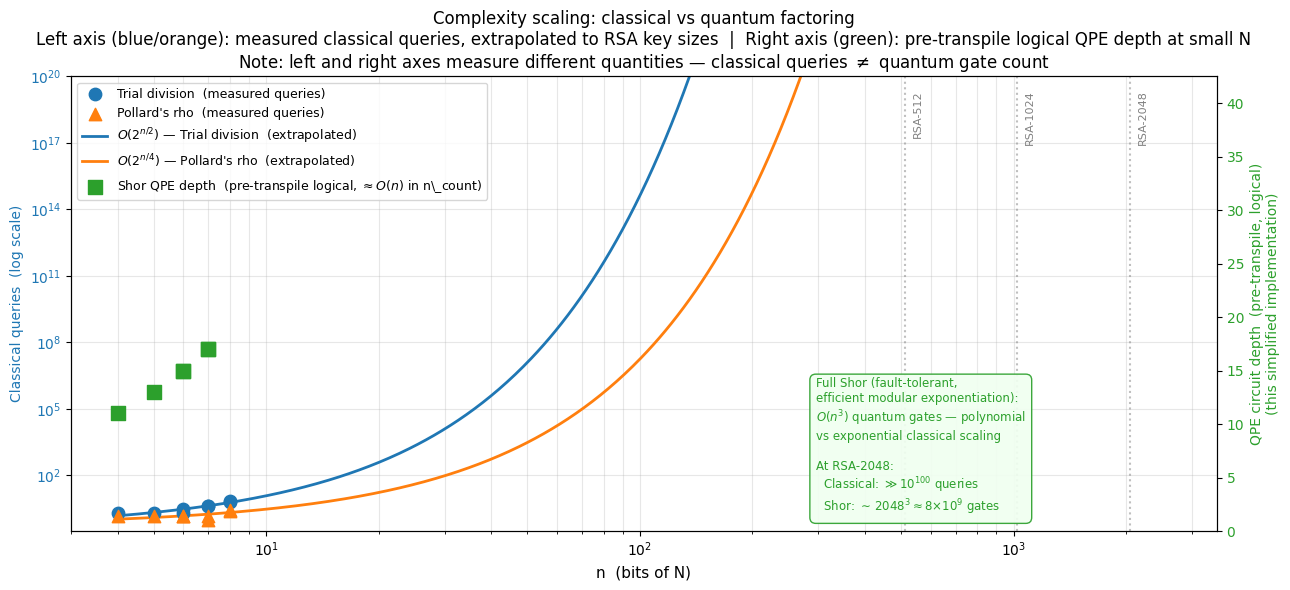

In [12]:
n_bits_arr = np.array(results['n_bits'], dtype=float)
trial_q    = np.array(results['trial_queries'])
pollard_q  = np.array(results['pollard_queries'])

# Only cases where Shor simulation ran (not skipped)
shor_idx       = [i for i, d in enumerate(results['shor_depth']) if d is not None]
shor_nbits     = np.array([results['n_bits'][i]    for i in shor_idx], dtype=float)
shor_depth_arr = np.array([results['shor_depth'][i] for i in shor_idx], dtype=float)

# Log-spaced x range for smooth extrapolation curves
n_ext = np.logspace(np.log10(4), np.log10(2048), 500)

# Fit classical complexity constants by log-linear regression
C_trial   = np.exp(np.mean(np.log(trial_q)   - (n_bits_arr / 2) * np.log(2)))
C_pollard = np.exp(np.mean(np.log(pollard_q) - (n_bits_arr / 4) * np.log(2)))

th_trial_ext   = C_trial   * 2 ** (n_ext / 2)
th_pollard_ext = C_pollard * 2 ** (n_ext / 4)

fig, ax1 = plt.subplots(figsize=(13, 6))

# Left axis — classical queries (measured + exponential extrapolation)
ax1.scatter(n_bits_arr, trial_q,   marker='o', color='tab:blue',   s=80, zorder=5,
            label=r'Trial division  (measured queries)')
ax1.scatter(n_bits_arr, pollard_q, marker='^', color='tab:orange', s=80, zorder=5,
            label=r"Pollard's rho  (measured queries)")
ax1.plot(n_ext, th_trial_ext,   color='tab:blue',   lw=2,
         label=r'$O(2^{n/2})$ — Trial division  (extrapolated)')
ax1.plot(n_ext, th_pollard_ext, color='tab:orange', lw=2,
         label=r"$O(2^{n/4})$ — Pollard's rho  (extrapolated)")

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('n  (bits of N)', fontsize=11)
ax1.set_ylabel('Classical queries  (log scale)', color='tab:blue', fontsize=10)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xlim(3, 3500)
ax1.set_ylim(0.3, 1e20)   # clips exponential curves off the top — intentional

# Right axis — pre-transpile logical depth (qc.depth() before transpile; IQFT counted as 1 instruction)
ax2 = ax1.twinx()
ax2.scatter(shor_nbits, shor_depth_arr, marker='s', color='tab:green', s=100, zorder=5,
            label=r'Shor QPE depth  (pre-transpile logical, $\approx O(n)$ in n\_count)')
ax2.set_ylabel('QPE circuit depth  (pre-transpile, logical)\n(this simplified implementation)',
               color='tab:green', fontsize=10)
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.set_ylim(0, max(shor_depth_arr) * 2.5)

# RSA reference lines
for nbits, lbl in [(512, 'RSA-512'), (1024, 'RSA-1024'), (2048, 'RSA-2048')]:
    ax1.axvline(nbits, color='gray', linestyle=':', alpha=0.5)
    ax1.text(nbits * 1.05, 0.97, lbl, color='gray', fontsize=8, rotation=90,
             va='top', transform=ax1.get_xaxis_transform())

# Annotation in lower-right: both classical curves exit the top of the chart before
# n≈270 bits, so the area to the right of that is empty — safe for the text box.
# Shor's theoretical advantage is noted here rather than plotted, since classical
# queries and quantum gate counts are incommensurable units.
ax1.text(0.65, 0.03,
         "Full Shor (fault-tolerant,\nefficient modular exponentiation):\n"
         r"$O(n^3)$ quantum gates — polynomial" + "\nvs exponential classical scaling\n\n"
         "At RSA-2048:\n"
         r"  Classical: $\gg 10^{100}$ queries" + "\n"
         r"  Shor: ${\sim}\,2048^3 \approx 8{\times}10^9$ gates",
         transform=ax1.transAxes, fontsize=8.5, color='tab:green', va='bottom', ha='left',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='honeydew',
                   edgecolor='tab:green', alpha=0.92))

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, fontsize=9, loc='upper left')

ax1.set_title(
    'Complexity scaling: classical vs quantum factoring\n'
    'Left axis (blue/orange): measured classical queries, extrapolated to RSA key sizes  |  '
    'Right axis (green): pre-transpile logical QPE depth at small N\n'
    r'Note: left and right axes measure different quantities — classical queries $\neq$ quantum gate count'
)
ax1.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# PLOT 2 — QPE success rate vs n_count

N=33 is used here because with the **correct** modular-exponentiation circuit it is a more informative test case than N=21 (which always succeeds trivially).

The true period of 2 mod 33 is **r=10**. The QPE produces 10 roughly equiprobable peaks, one for each phase k/10 (k=0..9). Of these, only **k=5 (phase 1/2)** leads to factoring:

| r candidate | even? | x = 2^(r/2) mod 33 | gcd(x−1,33) | gcd(x+1,33) | factors? |
|---|---|---|---|---|---|
| r=10 | ✓ | 2^5=32 | gcd(31,33)=1 | gcd(33,33)=33 | ✗ |
| r=5  | ✗ | — | — | — | ✗ |
| r=2  | ✓ | 2^1=2  | gcd(1,33)=1  | gcd(3,33)=3  | **✓** |

r=2 is obtained from k=5 (continued fraction of 5/10 = 1/2 → denominator 2).

**Expected behaviour of the correct circuit:**

With `shots=2000` and 10 peaks of roughly equal height (~200 shots each), `extract_period_candidates` collects all peaks in the top-12 list, so k=5 is always tried. The success rate should be near **100%** for any n_count large enough to resolve the 10 phases without aliasing (n_count ≥ ⌈log₂(r²)⌉ ≈ 7). At very small n_count the peaks overlap and success may drop. The recommended minimum 2·⌈log₂N⌉=12 gives well-separated peaks and reliable factoring.

**Implementation note — gate caching:** `pow(2, 2^j, 33)` cycles through only 5 distinct values {2, 4, 16, 25, 31} for all j. The sweep pre-decomposes each of these 5 controlled unitaries once (the expensive step), then assembles each QPE circuit from cached gates — reducing transpilation work from O(Σ n_count) ≈ 99 decompositions to just 5.

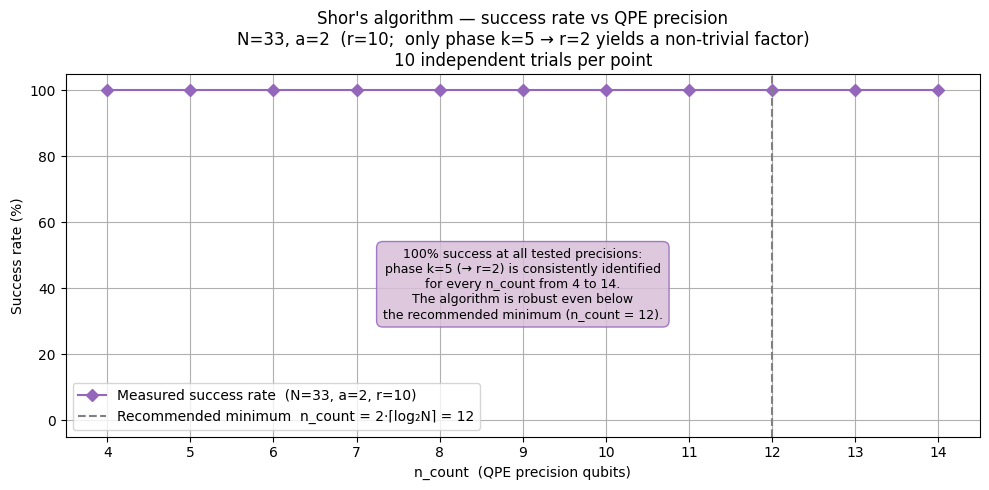

In [13]:
# Success rate vs QPE precision qubits (N = 33, a = 2, ord_33(2) = 10)
# Of the 10 phases k/10 (k=1..9), only k=5 → phase 1/2 → r=2 leads to factoring:
#   gcd(2^1 - 1, 33) = 1,  gcd(2^1 + 1, 33) = 3  ✓
# Other denominators: r=5 (odd → skip), r=10 (gcd(2^5-1,33)=1, gcd(2^5+1,33)=33 → fails).
# The vertical dashed line marks the recommended minimum n_count = 2·⌈log₂N⌉.

n_min_theory = 2 * SUCCESS_N.bit_length()

plt.figure(figsize=(10, 5))
plt.plot(SUCCESS_N_COUNTS, [s * 100 for s in success_rates],
         'D-', color='tab:purple',
         label=f'Measured success rate  (N={SUCCESS_N}, a={SUCCESS_A}, r=10)')
plt.axvline(n_min_theory, color='gray', linestyle='--',
            label=f'Recommended minimum  n_count = 2·⌈log₂N⌉ = {n_min_theory}')
plt.xlabel('n_count  (QPE precision qubits)')
plt.ylabel('Success rate (%)')
plt.title(
    f"Shor's algorithm — success rate vs QPE precision\n"
    f"N={SUCCESS_N}, a={SUCCESS_A}  (r=10;  only phase k=5 → r=2 yields a non-trivial factor)\n"
    f"{SUCCESS_TRIALS} independent trials per point"
)
plt.ylim(-5, 105)
plt.xticks(SUCCESS_N_COUNTS)
plt.legend()
plt.grid(True)

# The flat 100% line is itself the result: the correct QPE circuit reliably
# identifies phase k=5 at every tested precision, confirming the algorithm is
# robust well below the recommended minimum of n_count=12.
plt.text(0.50, 0.42,
         "100% success at all tested precisions:\nphase k=5 (→ r=2) is consistently identified\n"
         "for every n_count from 4 to 14.\n"
         "The algorithm is robust even below\nthe recommended minimum (n_count = 12).",
         transform=plt.gca().transAxes, fontsize=9, ha='center', va='center',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='thistle',
                   edgecolor='tab:purple', alpha=0.85))

plt.tight_layout()
plt.show()

# PLOT 3 — QPE measurement histogram

Histogram of QPE measurement outcomes for N=15, a=7 (true period r=4).

With `n_count=8` counting qubits and period r=4, the QPE concentrates probability at positions k·2⁸/4 = k·64 for k=0,1,2,3. Each non-zero peak is decoded by the continued-fractions algorithm to a period candidate, all of which yield non-trivial factors of 15.

This plot shows *why* the quantum algorithm works: the IQFT maps the uniform superposition into sharp peaks at phases 2πk/r, making the period extractable from classical post-processing.

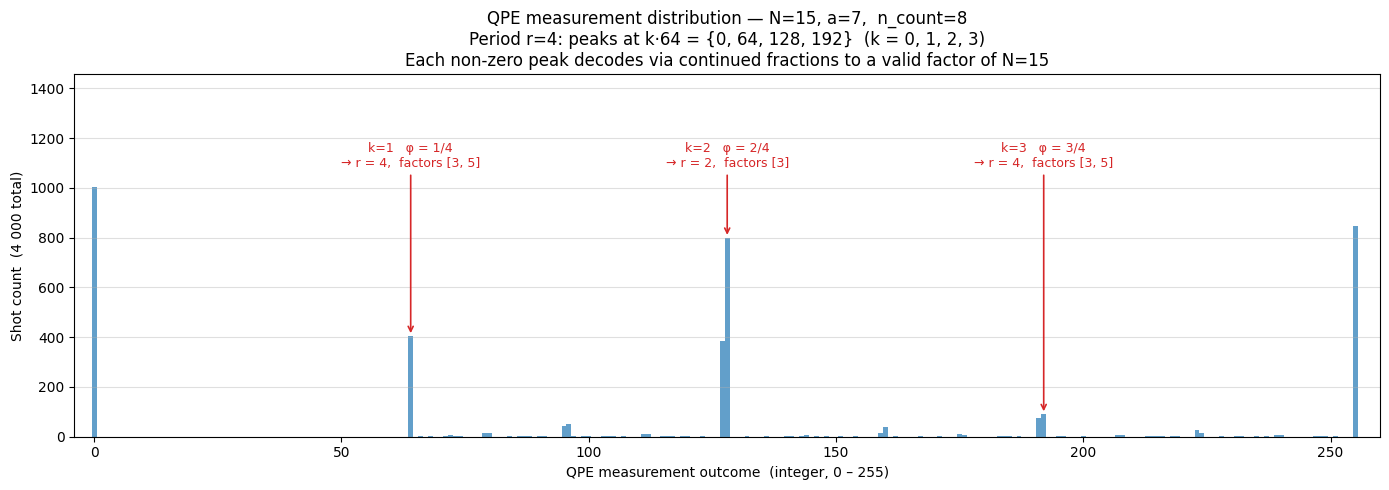

In [14]:
# Plot 3 — QPE measurement histogram: N=15, a=7, ord_15(7)=4, n_count=8
N_A, a_A, n_count_A, r_A = 15, 7, 8, 4

qc_A      = shor_qpe_circuit(N_A, a_A, n_count_A)
backend_A = AerSimulator()
counts_A  = backend_A.run(transpile(qc_A, backend_A), shots=4000).result().get_counts()

dim_A = 2 ** n_count_A
x_A   = np.arange(dim_A)
y_A   = np.array([counts_A.get(format(i, f'0{n_count_A}b'), 0) for i in x_A])

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x_A, y_A, color='tab:blue', alpha=0.7, width=1.0)

for k in range(1, r_A):
    pos    = k * dim_A // r_A          # expected peak: k·64 ∈ {64, 128, 192}
    r_cand = Fraction(k, r_A).denominator
    if r_cand % 2 == 0:
        xf      = pow(a_A, r_cand // 2, N_A)
        factors = sorted({f for f in [gcd(xf - 1, N_A), gcd(xf + 1, N_A)] if 1 < f < N_A})
        fstr    = f'factors {factors}'
    else:
        fstr = 'r odd → skip'
    ax.annotate(
        f'k={k}   φ = {k}/{r_A}\n→ r = {r_cand},  {fstr}',
        xy=(pos, y_A[pos]),
        xytext=(pos, max(y_A) * 1.08),
        ha='center', fontsize=9, color='tab:red',
        arrowprops=dict(arrowstyle='->', color='tab:red', lw=1.2)
    )

ax.set_xlabel(f'QPE measurement outcome  (integer, 0 – {dim_A - 1})')
ax.set_ylabel('Shot count  (4 000 total)')
ax.set_title(
    f'QPE measurement distribution — N={N_A}, a={a_A},  n_count={n_count_A}\n'
    f'Period r=4: peaks at k·{dim_A // r_A} = {{0, 64, 128, 192}}  (k = 0, 1, 2, 3)\n'
    'Each non-zero peak decodes via continued fractions to a valid factor of N=15'
)
ax.set_xlim(-4, dim_A + 4)
ax.set_ylim(0, max(y_A) * 1.45)
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# PLOT 4 — Simulation vs real IBM hardware

Compares factoring success and noise level for the four cases run on real IBM quantum hardware (N ≤ 35).

`Top-outcome probability` is the fraction of shots that land on a single measurement outcome. On real hardware it acts as a noise proxy: a well-resolved QPE peak gives a high value, while full depolarisation gives ≈ 1/2^n_count ≈ 0%. The top-outcome probability generally decreases as circuits grow larger and noisier, though the exact value also depends on the specific phase structure — cases where a single dominant phase exists (e.g. N=33, phase 1/2 from k=5) can achieve higher probability than shallower circuits with more spread-out peak distributions.


**Spurious period — N=35 (★ in plot).** The hardware reported success with r=16, but ord₃₅(2) = 12 (since 2¹² ≡ 1 mod 35, while 2¹⁶ ≡ 16 mod 35 ≠ 1). A noise-distorted QPE measurement produced a continued-fraction approximation with denominator 16, and the GCD step succeeded by chance: 2⁸ mod 35 = 11, gcd(10, 35) = 5 ✓. This is **noise-assisted factoring**, not genuine period finding — the factor was obtained despite, not because of, a valid QPE result.

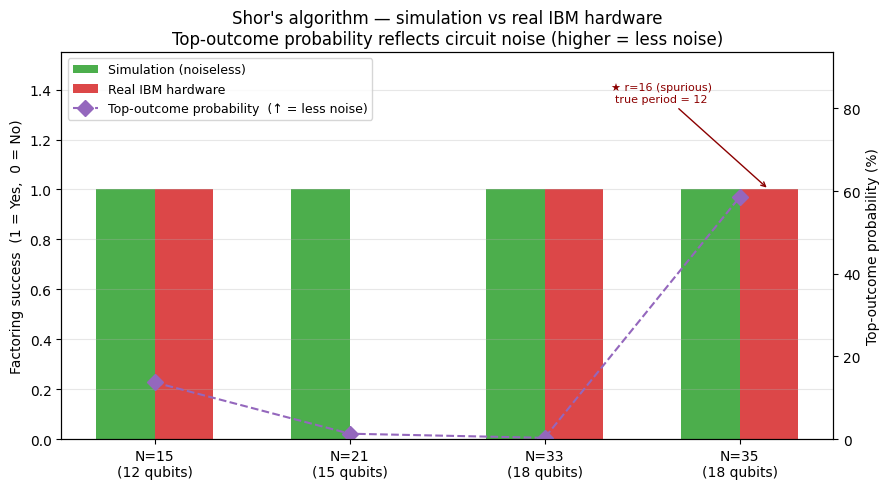

In [18]:
# Plot 4 — Simulation vs real IBM hardware: success and top-outcome probability (noise proxy)
real_idx   = [i for i in range(len(results['N'])) if results['shor_real_ran'][i]]
sim_ok_B   = [int(results['shor_correct'][i])      for i in real_idx]
real_ok_B  = [int(results['shor_real_correct'][i]) for i in real_idx]
top_prob_B = [results['shor_real_top_prob'][i] * 100 for i in real_idx]

x_B   = np.arange(len(real_idx))
width = 0.3

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(x_B - width / 2, sim_ok_B,  width, color='tab:green', alpha=0.85, label='Simulation (noiseless)')
ax1.bar(x_B + width / 2, real_ok_B, width, color='tab:red',   alpha=0.85, label='Real IBM hardware')
ax1.set_ylabel('Factoring success  (1 = Yes,  0 = No)')
ax1.set_ylim(0, 1.55)
ax1.set_xticks(x_B)
ax1.set_xticklabels([
    f"N={results['N'][i]}\n({results['n_count'][i] + results['n_bits'][i]} qubits)"
    for i in real_idx
])

ax2 = ax1.twinx()
ax2.plot(x_B, top_prob_B, 'D--', color='tab:purple', markersize=8,
         label='Top-outcome probability  (↑ = less noise)')
ax2.set_ylabel('Top-outcome probability (%)')
ax2.set_ylim(0, max(top_prob_B) * 1.6)

# Flag N=35 if real hardware succeeded via a spurious period (r=16 ≠ true period 12)
real_n35 = [(pos, i) for pos, i in enumerate(real_idx) if results['N'][i] == 35]
if real_n35 and results['shor_real_correct'][real_n35[0][1]]:
    pos35 = real_n35[0][0]
    ax1.annotate(
        '★ r=16 (spurious)\ntrue period = 12',
        xy=(x_B[pos35] + width / 2, 1.0),
        xytext=(x_B[pos35] - 0.4, 1.35),
        fontsize=8, color='darkred', ha='center',
        arrowprops=dict(arrowstyle='->', color='darkred', lw=1.0)
    )

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc='upper left', fontsize=9)
ax1.set_title(
    "Shor's algorithm — simulation vs real IBM hardware\n"
    'Top-outcome probability reflects circuit noise (higher = less noise)'
)
ax1.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# PRINT SUMMARY

In [16]:
header = (
    f"{'N':>6} {'bits':>5} {'n_count':>8} {'Trial Q':>9} {'Pollard Q':>10} "
    f"{'QPE depth':>10} {'Sim OK':>7} {'Real total':>11} {'Real OK':>8} {'Top prob':>9}"
)
print(header)
print("-" * len(header))
for i in range(len(results['N'])):
    ran      = results['shor_real_ran'][i]
    t_total  = f"{results['shor_real_time_total'][i]:.2f}s" if ran else 'N/A'
    real_ok  = 'Yes' if results['shor_real_correct'][i] else ('No' if ran else 'N/A')
    top_prob = f"{results['shor_real_top_prob'][i]:.1%}" if ran else 'N/A'
    depth    = results['shor_depth'][i]
    sim_ok   = results['shor_correct'][i]
    print(
        f"{results['N'][i]:>6} "
        f"{results['n_bits'][i]:>5} "
        f"{results['n_count'][i]:>8} "
        f"{results['trial_queries'][i]:>9.1f} "
        f"{results['pollard_queries'][i]:>10.1f} "
        f"{'N/A' if depth is None else depth:>10} "
        f"{'Skip' if sim_ok is None else ('Yes' if sim_ok else 'No'):>7} "
        f"{t_total:>11} "
        f"{real_ok:>8} "
        f"{top_prob:>9}"
    )

print(f"\nSuccess-rate sweep  (N={SUCCESS_N}, a={SUCCESS_A}, r=10, {SUCCESS_TRIALS} trials each):")
print(f"  {'n_count':>8}  {'success':>8}")
print("  " + "-" * 19)
for nc, rate in zip(SUCCESS_N_COUNTS, success_rates):
    marker = '  <- recommended minimum' if nc == 2 * SUCCESS_N.bit_length() else ''
    print(f"  {nc:>8}  {rate:>7.0%}{marker}")

     N  bits  n_count   Trial Q  Pollard Q  QPE depth  Sim OK  Real total  Real OK  Top prob
--------------------------------------------------------------------------------------------
    15     4        8       2.0        1.4         11     Yes      13.01s      Yes     13.7%
    21     5       10       2.0        1.4         13     Yes      25.71s       No      1.3%
    33     6       12       2.0        1.4         15     Yes      66.34s      Yes      0.3%
    35     6       12       3.0        1.4         15     Yes      66.06s      Yes     58.5%
    77     7       14       4.0        1.4         17     Yes         N/A      N/A       N/A
    91     7       14       4.0        1.0         17     Yes         N/A      N/A       N/A
   143     8       16       6.0        2.4        N/A    Skip         N/A      N/A       N/A
   221     8       16       7.0        2.8        N/A    Skip         N/A      N/A       N/A

Success-rate sweep  (N=33, a=2, r=10, 10 trials each):
   n_count   s

## Notes on the implementation

The QPE circuit uses exact permutation unitaries U|y⟩ = |a·y mod N⟩ for the modular exponentiation, producing genuine phase kickback. The eigenvalues of U are e^(2πi·k/r) (k=0..r-1), and the IQFT maps the counting register to measurement peaks at multiples of 2^n_count / r.

**Sub-period extraction.** The continued-fractions step may return a divisor of the true period r rather than r itself. For example, N=91 (ord₉₁(2)=12) produces a peak near position 2·2¹⁴/12 ≈ 2731, whose best rational approximation with denominator ≤ 91 is 1/6 → r=6. Even though 6 ≠ 12, the GCD step succeeds: gcd(2³−1, 91) = gcd(7, 91) = 7 ✓. Sub-periods yield non-trivial factors whenever a^(r/2) ≢ ±1 (mod N).

**Circuit depth and real hardware.** The unitary matrices are 2^n_target × 2^n_target, so the transpiled circuits contain thousands of basis gates even for small N. For the real-hardware cases (N ≤ 35) this produces deep circuits that accumulate significant gate error; `top_prob` values reflect this noise. The quantum advantage in execution time is absent at this scale.

**Scalability.** Building the full unitary matrix is exponential in n_bits and is only tractable for small N. A production Shor implementation replaces this with an efficient quantum circuit for modular multiplication (O(n²) or O(n³) gates), which is the basis of the true polynomial-time quantum advantage.